In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Directory for Sean

In [ ]:
%cd /content/drive/MyDrive/NLP Team Project/Code

/content/drive/MyDrive/NLP Team Project/Code


**PART 1: Load the ground truths**

In [ ]:
import json

In [ ]:
with open('ground_truths.json', 'r', encoding='utf8') as file:
    ground_truths = json.load(file)

In [ ]:
# X = list of article texts
X = list(ground_truths.keys())

In [ ]:
"""
y = list of int vectors
Each vector is of length k, where k is the number of clusters that we have previously determined
In a vector, the i-th element is 0 if it's not an issue mentioned by the article, and otherwise its value is the severity score of the issue mentioned by the article
Cluster 0: Comprehensive Environmental & Socio‑Economic Challenges
Cluster 1: Global Water Sustainability, Governance, and Public Health Challenges
Cluster 2: Industrialization’s Impact on Cultural, Indigenous, and Ecological Heritage
Cluster 3: Sustainable Practices Across Sectors
Cluster 4: Sustainable Green Development & Equity
Cluster 5: Political Dynamics and Power in Environmental Governance
Cluster 6: Waste Management & Environmental Impact
Cluster 7: Environmental Health & Ecosystem Well‑Being
Cluster 8: Agricultural & Climate Policy Landscape
Cluster 9: Environmental Governance, Justice, and Impact
Cluster 10: Public Environmental Governance & Public Perception
Cluster 11: Energy Transition Dynamics
e.g. If only topics 2 and 7 are issues in the article with severity scores of 6 and 4, respectively,
then everything in the vector is 0 except the 2nd and 7th elements (with values of 6 and 4 respectively).
"""
k = 12 # number of clusters (as identifed by our KMeans clustering earlier)
issues_mapping = {"Comprehensive Environmental & Socio‑Economic Challenges": 0,
                  "Global Water Sustainability, Governance, and Public Health Challenges": 1,
                  "Industrialization’s Impact on Cultural, Indigenous, and Ecological Heritage": 2,
                  "Sustainable Practices Across Sectors": 3,
                  "Sustainable Green Development & Equity": 4,
                  "Political Dynamics and Power in Environmental Governance": 5,
                  "Waste Management & Environmental Impact": 6,
                  "Environmental Health & Ecosystem Well‑Being": 7,
                  "Agricultural & Climate Policy Landscape": 8,
                  "Environmental Governance, Justice, and Impact": 9,
                  "Public Environmental Governance & Public Perception": 10,
                  "Energy Transition Dynamics": 11}
y = []
for article_issues in ground_truths.values(): # article_issues is a dict that maps an environmental issue to a severity score
    vector = [0] * k
    for issue, score in article_issues.items():
        if issue not in issues_mapping:
            continue # Go to the next iteration of the issue/score loop
        else:
            vector[issues_mapping[issue]] = score
    y.append(vector)

**PART 2: Train a neural network to identify environmental issues and their severity scores from the news articles**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional, Attention, GlobalMaxPooling1D
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [ ]:
# Tokenize the article texts.
tokenizer = Tokenizer(num_words=100000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
X = pad_sequences(sequences, maxlen=100)

In [ ]:
# Build model
model = Sequential([
    Embedding(100000, 128, input_length=10000),

    # Bidirectional LSTM to capture both forward and backward context
    Bidirectional(LSTM(64, return_sequences=False)),

    # Add Dropout after LSTM to prevent overfitting
    Dropout(0.3),

    # LSTM layer for deeper feature extraction
    #LSTM(64, return_sequences=True),

    # Global max pooling to reduce the sequence dimension
    #GlobalMaxPooling1D(),

    # Dense layer with L2 regularization and Dropout
    Dense(64, activation='relu'),
    Dropout(0.4),  # Dropout for regularization
    Dense(32, activation='relu'),

    # Output layer with linear activation
    Dense(k, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7650)
X_train = np.array(X_train, dtype=np.int32)
X_test = np.array(X_test, dtype=np.int32)
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [ ]:
X_train

array([[   2,  319,   18, ...,    5, 1122,   96],
       [   5, 5640, 5641, ...,    3,  334,   29],
       [4035,   16, 1139, ...,    5, 4050,   29],
       ...,
       [   8,    2,  427, ...,   41, 2748,   29],
       [1185,  274, 1186, ..., 2629, 4525, 2629],
       [ 251,   48, 6980, ...,   24,  375,   29]], dtype=int32)

In [ ]:
y_train

array([[ 8.,  0.,  6.,  0.,  0.,  0.,  6.,  0.,  5.,  0.,  0.,  0.],
       [ 7.,  0.,  8.,  9.,  8.,  0.,  7.,  6.,  7.,  0.,  7.,  0.],
       [ 9.,  0.,  0.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,  0.,  0.],
       [ 7.,  0.,  0.,  0.,  0.,  0.,  7.,  0.,  0.,  0.,  3.,  0.],
       [ 8.,  0.,  7.,  0.,  0.,  0.,  6.,  5.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  9., 10., 10.,  0.,  8.,  0.,  8.,  0.,  0.,  0.],
       [ 0.,  0.,  6.,  7.,  9.,  0.,  6.,  4.,  6.,  0.,  3.,  0.],
       [ 5.,  0.,  0.,  7.,  0.,  0.,  4.,  3.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  7.,  0.,  7.,  0.,  6.,  0.,  0.,  0.,  9.,  0.],
       [ 9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 6.,  0.,  7.,  8.,  7.,  0.,  6.,  5.,  6.,  0.,  6.,  0.],
       [ 8.,  0.,  0.,  0.,  5.,  0.,  6.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  6.,  7.,  8.,  0.,  6.,  4.,  5.,  0.,  5.,  0.],
       [ 0.,  0.,  6.,  8.,  9.,  0.,  7.,  5.,  7.,  0.,  5.,  0.],
       [ 3.,  0.,  0.,  0.,  0.,  

In [ ]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), loss='mean_squared_error', metrics=['mae', 'mse'])

In [ ]:
# Fit the model on the train data
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 13.6536 - mae: 1.9123 - mse: 13.6536 - val_loss: 12.7202 - val_mae: 1.7889 - val_mse: 12.7202
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.3905 - mae: 1.8758 - mse: 11.3905 - val_loss: 10.1662 - val_mae: 2.3161 - val_mse: 10.1662
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.3586 - mae: 2.4319 - mse: 10.3586 - val_loss: 9.2104 - val_mae: 2.2340 - val_mse: 9.2104
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.6409 - mae: 2.1998 - mse: 8.6409 - val_loss: 8.7538 - val_mae: 2.3329 - val_mse: 8.7538
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.9445 - mae: 2.3322 - mse: 8.9445 - val_loss: 8.5272 - val_mae: 2.2099 - val_mse: 8.5272
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.3089 - mae: 2.1655 - mse: 8.3089 - val_loss: 8.5062 - val_mae: 2.1140 - val_mse: 8.5062
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.5457 - mae: 2.0937 - mse: 7.5457 - 

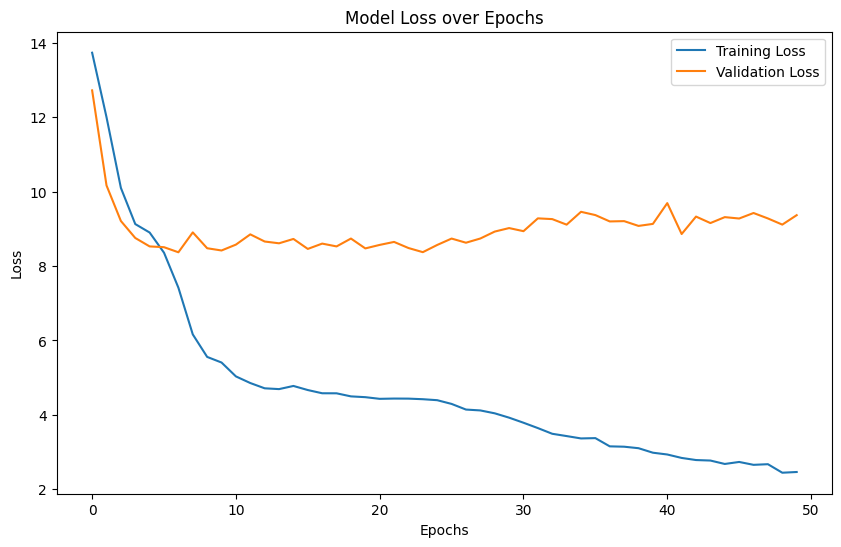

In [ ]:
# Plot training & validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Part 3: Visualize the results**

Plot MAE of each environmental issue. This shows which issues the neural network does best in identifying and evaluating, and which ones it struggles the most with identifying/evaluating.

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
['Comprehensive Environmental & Socio‑Economic Challenges', 'Global Water Sustainability, Governance, and Public Health Challenges', 'Industrialization’s Impact on Cultural, Indigenous, and Ecological Heritage', 'Sustainable Practices Across Sectors', 'Sustainable Green Development & Equity', 'Political Dynamics and Power in Environmental Governance', 'Waste Management & Environmental Impact', 'Environmental Health & Ecosystem Well‑Being', 'Agricultural\u202f&\u202fClimate Policy Landscape', 'Environmental Governance, Justice, and Impact', 'Public Environmental Governance & Public Perception', 'Energy Transition Dynamics']


/tmp/ipython-input-594420080.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(issue_names))


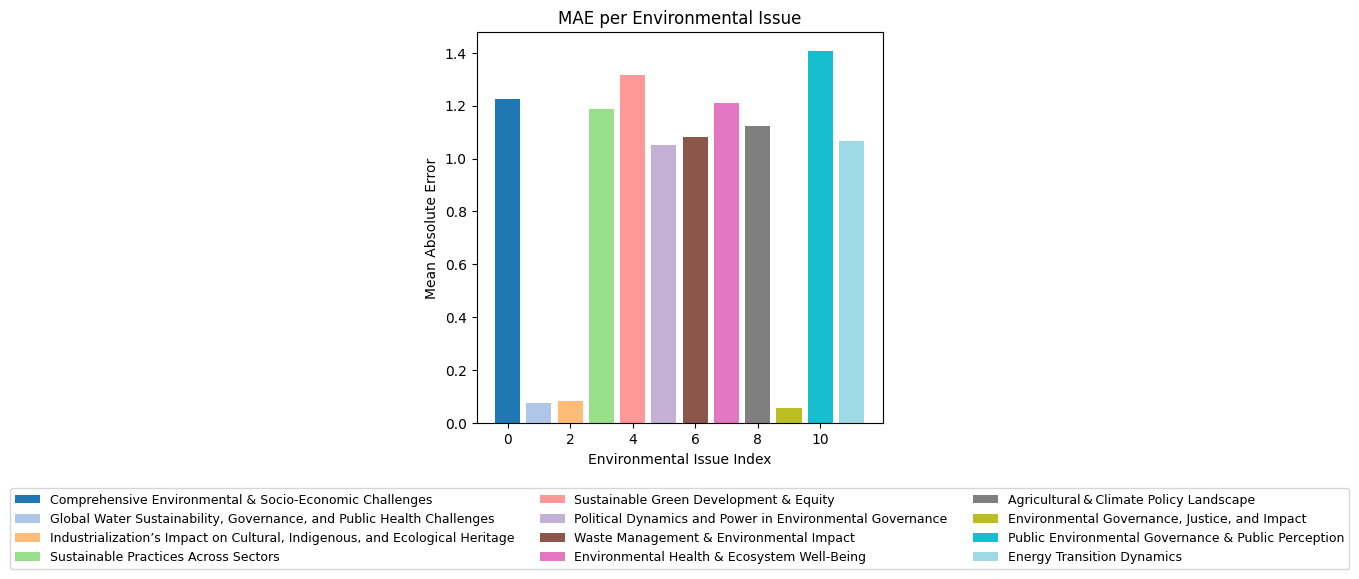

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for each environmental issue (column)
y_pred = model.predict(X_train)
mae_per_issue = [mean_absolute_error(y_train[:, i], y_pred[:, i]) for i in range(k)]

issue_names = list(issues_mapping.keys())
print(issue_names)

# Create a color map to assign a unique color for each issue
colors = plt.cm.get_cmap("tab20", len(issue_names))

# Plot the MAE for each environmental issue
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(mae_per_issue)), mae_per_issue, color=colors(range(len(mae_per_issue))))

# Add labels, title, and other decorations
plt.xlabel('Environmental Issue Index')
plt.ylabel('Mean Absolute Error')
plt.title('MAE per Environmental Issue')

# Set x-axis labels with the issue names and rotate them for better readability
#plt.xticks(range(len(issue_names)), issue_names, rotation=45, fontsize=10)

# Add a legend at the bottom with each environmental issue's color
plt.legend(bars, issue_names, bbox_to_anchor=(0.5, -0.15), loc='upper center', fontsize=9, ncol=3)

# Show the plot
plt.tight_layout()
plt.show()


From the output of the model, compute F1 score for each of the $k$ environmental issues.

- If an issue's severity score is non-zero, that means the model identifies it as an issue. If an issue's severity score is zero, that means the model did not identify it as an issue.

- In the the ground truths' output (accessible through y), if an issue's severity score is non-zero, then it is actually an issue. If an issue's severity score is zero, then it is actually not an issue.

In [ ]:
from sklearn.metrics import f1_score

# Predict severity scores for all of X
y_pred_all = model.predict(X)

# Convert predicted and true severity scores to binary (0 or 1)
y_pred_binary = (y_pred_all > 0).astype(int)
y_true_binary = (np.array(y) > 0).astype(int)

# Calculate F1 score for each environmental issue
f1_scores_per_issue = [f1_score(y_true_binary[:, i], y_pred_binary[:, i]) for i in range(k)]

# Print the F1 scores for each issue
issue_names = list(issues_mapping.keys())
for i, f1 in enumerate(f1_scores_per_issue):
    print(f"F1 Score for '{issue_names[i]}': {f1:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
F1 Score for 'Comprehensive Environmental & Socio‑Economic Challenges': 0.6933
F1 Score for 'Global Water Sustainability, Governance, and Public Health Challenges': 0.0000
F1 Score for 'Industrialization’s Impact on Cultural, Indigenous, and Ecological Heritage': 0.0000
F1 Score for 'Sustainable Practices Across Sectors': 0.6143
F1 Score for 'Sustainable Green Development & Equity': 0.5831
F1 Score for 'Political Dynamics and Power in Environmental Governance': 0.6544
F1 Score for 'Waste Management & Environmental Impact': 0.3534
F1 Score for 'Environmental Health & Ecosystem Well‑Being': 0.7758
F1 Score for 'Agricultural & Climate Policy Landscape': 0.3680
F1 Score for 'Environmental Governance, Justice, and Impact': 0.0000
F1 Score for 'Public Environmental Governance & Public Perception': 0.6857
F1 Score for 'Energy Transition Dynamics': 0.4230
